In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import NamedTuple
from copy import deepcopy

import numpy as np
import scanpy as sc
import sklearn as sk
from scipy.stats import pearsonr, spearmanr, rankdata

import matplotlib.pyplot as plt

### Data Utils

In [2]:
class Result(NamedTuple):
    original_counts: np.ndarray
    predicted_counts: np.ndarray

def filter_by_obs(adata, column_name, column_value):
    return adata[adata.obs[column_name] == column_value].copy()

def training_testing_masks(
    n,
    fraction_training,
    np_seed = 0
):
    rng = np.random.default_rng(np_seed)
    training_mask = rng.choice([True, False], size=n, p=[fraction_training, 1-fraction_training])
    testing_mask = ~training_mask
    return training_mask, testing_mask

def training_testing_split_adata(
    adata,
    fraction_training,
    np_seed: int | None = 0
):
    training_mask, testing_mask = training_testing_masks(
        adata.n_obs,
        fraction_training,
        np_seed
    )
    return adata[training_mask].copy(), adata[testing_mask].copy()

def transform_return_value(func, transform_fn):
    def wrapper(*args, **kwargs):
        result = func(*args, **kwargs)
        transformed_result = transform_fn(result)
        return transformed_result
    return wrapper

def raw_correlation(correlation_func):
    def compute_correlation(result):
        return correlation_func(
            result.original_counts.mean(axis=0),
            result.predicted_counts.mean(axis=0),
        )
    return compute_correlation

def transform_correlation(correlation_func):
    def compute_correlation(result):
        return correlation_func(
            np.log(result.original_counts.mean(axis=0) + 1e-3),
            np.log(result.predicted_counts.mean(axis=0) + 1e-3),
        )
    return compute_correlation


### Loading Data

In [3]:
# Query Dataset
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs

# Reference Dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = np.array(list(set.intersection(set(adata_sp.var_names), set(adata_sc.var_names))))

adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [177]:
training_sc, testing_sc = training_testing_split_adata(
    filter_by_obs(adata_sc, "celltype", "Stem/TA")[:, shared_genes],
    2/3,
    0
)
testing_sp = filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes]

### Model Architecture

In [5]:
@dataclass
class LinearLayer:
    W: np.ndarray
    b: np.ndarray

    def forward(self, Z):
        return (Z @ self.W) + self.b
    
    def __call__(self, Z):
        return self.forward(Z)

def ReLU(Z):
    return np.maximum(0, Z)

In [145]:
@dataclass
class LinearLayer:
    W: np.ndarray
    b: np.ndarray

    def __post_init__(self):
        # Initialize gradients as zeros
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.input_cache = None  # Store input for backpropagation

    def forward(self, Z):
        self.input_cache = Z  # Save input for gradient computation
        return (Z @ self.W) + self.b
    
    def backward(self, dZ):
        """Compute gradients w.r.t. inputs and weights."""
        dW = self.input_cache.T @ dZ  # Compute gradient for weights
        db = np.sum(dZ, axis=0, keepdims=True)  # Compute gradient for bias

        dZ_prev = dZ @ self.W.T  # Backpropagate error to previous layer

        # Store computed gradients
        self.dW = dW
        self.db = db

        return dZ_prev  # Pass error backwards
    
    def __call__(self, Z):
        return self.forward(Z)

def ReLU(Z):
    return np.maximum(0, Z)

def ReLU_backward(dZ, Z):
    """Compute gradient of ReLU. If Z <= 0, gradient is 0; otherwise, it is 1."""
    dZ[Z <= 0] = 0
    return dZ


class Model:
    def __init__(self, n_input, n_latent, n_output):
        self.fc1 = LinearLayer(
            W=np.random.randn(n_input, n_latent) * np.sqrt(2 / (n_input + n_latent)),
            b=np.zeros((1, n_latent))
        )
        self.fc2 = LinearLayer(
            W=np.random.randn(n_latent, n_output) * np.sqrt(2 / (n_latent + n_output)),
            b=np.zeros((1, n_output))
        )

    def forward(self, Z):
        self.Z1 = self.fc1(Z)  # Linear layer 1
        self.A1 = ReLU(self.Z1)  # Activation
        self.Z2 = self.fc2(self.A1)  # Linear layer 2
        return self.Z2

    def backward(self, dZ2):
        """Backpropagate gradients through the network."""
        dA1 = self.fc2.backward(dZ2)  # Backprop through fc2
        dZ1 = ReLU_backward(dA1, self.Z1)  # Backprop through ReLU
        dX = self.fc1.backward(dZ1)  # Backprop through fc1
        return dX  # Gradient w.r.t. input

    def update_parameters(self, lr=0.01):
        """Update parameters using gradient descent."""
        self.fc1.W -= lr * self.fc1.dW
        self.fc1.b -= lr * self.fc1.db
        self.fc2.W -= lr * self.fc2.dW
        self.fc2.b -= lr * self.fc2.db

    def __call__(self, Z):
        return self.forward(Z)

### Training Loop

In [133]:
sc.pp.log1p(training_sc)
sc.pp.log1p(testing_sc)
sc.pp.log1p(testing_sp)

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:404: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [160]:

model = Model(training_sc.n_vars, 2, training_sc.n_vars)

In [126]:
model = Model(training_sc.n_vars, 2, training_sc.n_vars)
for _ in range(3):
    Y_pred = model(training_sc.X.toarray())
    dY = 2 * (Y_pred - training_sc.X.toarray()) / training_sc.X.toarray().shape[0]
    model.backward(dY)
    model.update_parameters(lr=0.01)

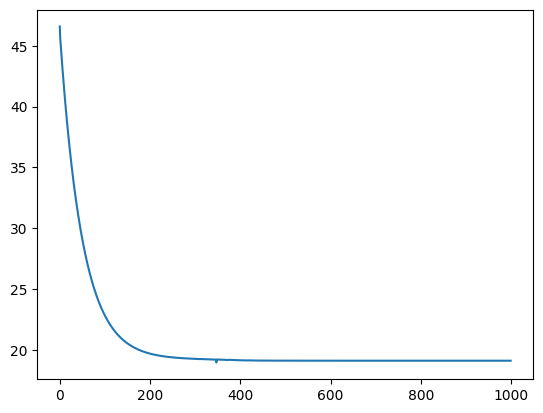

In [167]:
model = Model(training_sc.n_vars, 2, training_sc.n_vars)
models = []
losses = []
for _ in range(1000):
    Y_pred = model(training_sc.X.toarray())
    dY = 2 * (Y_pred - training_sc.X.toarray()) / training_sc.X.toarray().shape[0]
    models.append(deepcopy(model))
    losses.append(sk.metrics.mean_squared_error(training_sc.X.toarray(), Y_pred))
    model.backward(dY)
    model.update_parameters(lr=0.005)

plt.plot(losses)

### Performance evaluation

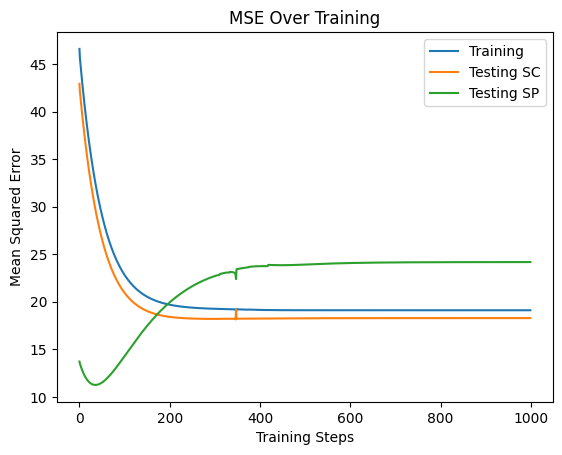

In [168]:
mse = np.array([
    np.fromiter(
        (sk.metrics.mean_squared_error(data, model(data)) for model in models),
        dtype=float
    )
    for data in [training_sc.X.toarray(), testing_sc.X.toarray(), testing_sp.X]
]).T

plt.plot(mse, label=["Training", "Testing SC", "Testing SP"])
plt.legend()
plt.xlabel("Training Steps")
plt.ylabel("Mean Squared Error")
plt.title("MSE Over Training")
plt.show()


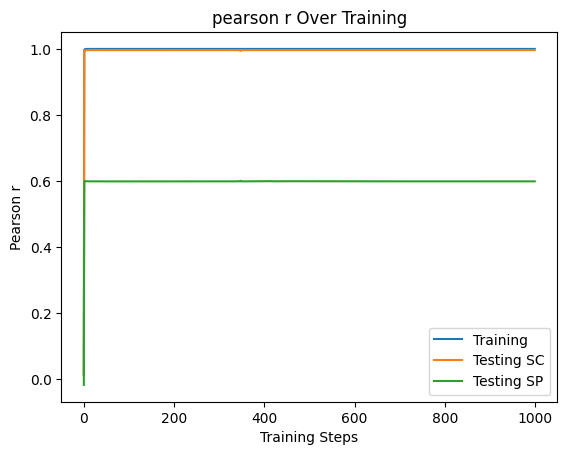

In [169]:
pearson = np.array([
    np.fromiter(
        (raw_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(predict_counts_from_model(data, model)) for model in models),
        dtype=float
    )
    for data in [training_sc.X.toarray(), testing_sc.X.toarray(), testing_sp.X]
]).T

plt.plot(pearson, label=["Training", "Testing SC", "Testing SP"])
plt.legend()
plt.xlabel("Training Steps")
plt.ylabel("Pearson r")
plt.title("pearson r Over Training")
plt.show()


In [186]:
np.random.permutation(testing_sp.X)

TypeError: permutation() got an unexpected keyword argument 'axis'

In [191]:
datasets[0].shape

(997, 40)

In [222]:
masks = np.vstack([np.random.choice(len(shared_genes), 100, replace=False) for _ in range(100)])

(-1.0, 1.0)

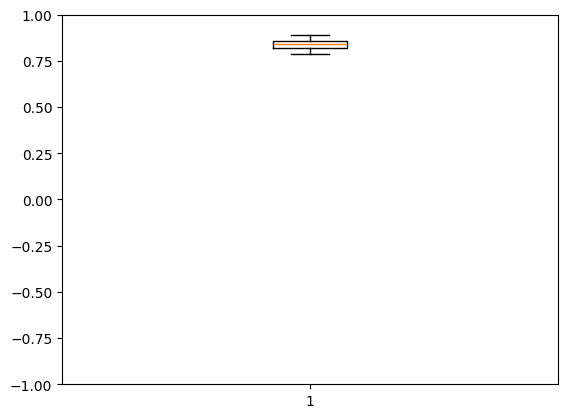

In [223]:
plt.boxplot([pearsonr(np.log(testing_sp.X[:, mask].mean(axis=0) + 1e-3), np.log(model(testing_sp.X)[:, mask].mean(axis=0) + 1e-3))[0] for mask in masks])
plt.ylim(-1, 1)

In [198]:
models[-1](testing_sp.X)

array([[ 2.39986297e-05, -2.07710637e-05,  9.20585922e-01, ...,
         2.10519642e-05,  1.70603449e-01,  1.79714084e+01],
       [ 2.39986297e-05, -2.07710637e-05,  9.20585922e-01, ...,
         2.10519642e-05,  1.70603449e-01,  1.79714084e+01],
       [ 3.09166710e-06, -2.60935443e-06,  7.34661050e-01, ...,
         2.53021560e-06,  1.36162987e-01,  1.57556026e+01],
       ...,
       [ 2.39986297e-05, -2.07710637e-05,  9.20585922e-01, ...,
         2.10519642e-05,  1.70603449e-01,  1.79714084e+01],
       [ 2.39986297e-05, -2.07710637e-05,  9.20585922e-01, ...,
         2.10519642e-05,  1.70603449e-01,  1.79714084e+01],
       [ 2.39986297e-05, -2.07710637e-05,  9.20585922e-01, ...,
         2.10519642e-05,  1.70603449e-01,  1.79714084e+01]])

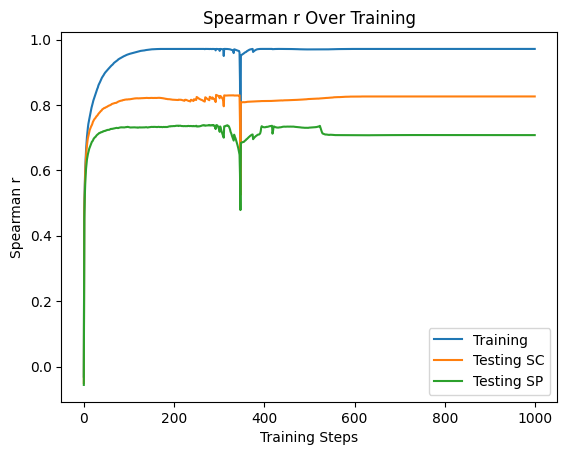

In [172]:
spearman = np.array([
    np.fromiter(
        (raw_correlation(transform_return_value(spearmanr, lambda x: float(x[0])))(predict_counts_from_model(data, model)) for model in models),
        dtype=float
    )
    for data in [training_sc.X.toarray(), testing_sc.X.toarray(), testing_sp.X]
]).T

plt.plot(spearman, label=["Training", "Testing SC", "Testing SP"])
plt.legend()
plt.xlabel("Training Steps")
plt.ylabel("Spearman r")
plt.title("Spearman r Over Training")
plt.show()

(-1.1, 1.1)

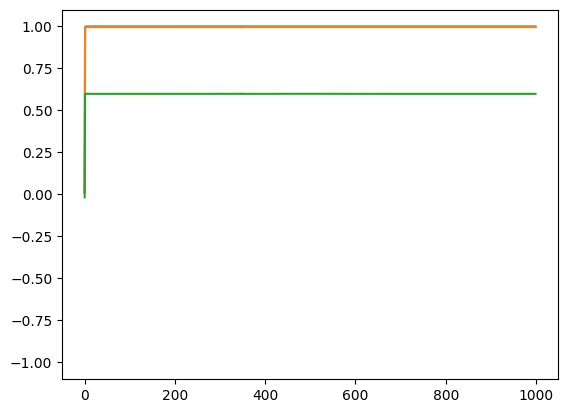

In [171]:
test = np.array([
    np.fromiter(
        (pearsonr(data.mean(axis=0), model(data).mean(axis=0))[0] for model in models),
        dtype=float
    )
    for data in [training_sc.X.toarray(), testing_sc.X.toarray(), testing_sp.X]
])
plt.plot(test.T)
plt.ylim(-1.1,1.1)

In [297]:
test = np.array([
    np.fromiter(
        (spearmanr(data.mean(axis=0), model(data).mean(axis=0))[0] for model in models),
        dtype=float
    )
    for data in [training_sc.X.toarray(), testing_sc.X.toarray(), testing_sp.X.toarray()]
])

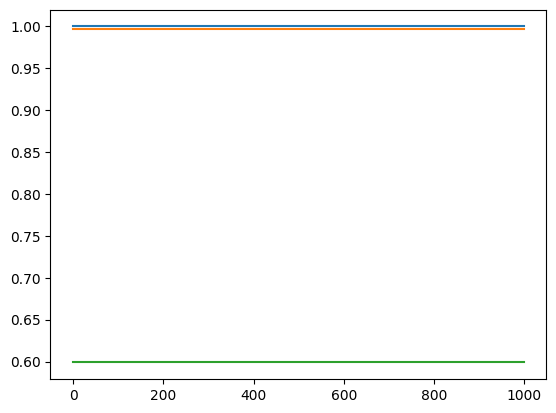

In [63]:
plt.plot(test.T)

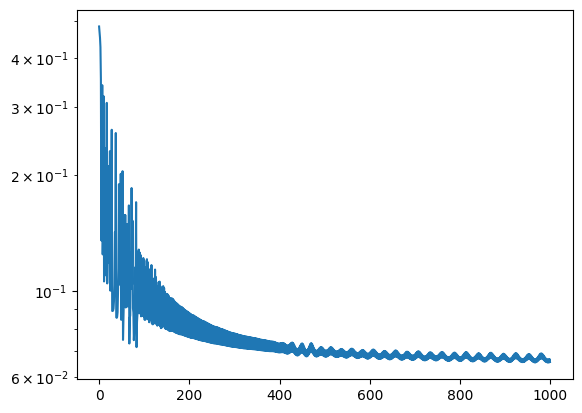

In [144]:
plt.plot(
    np.fromiter(map(lambda model: sk.metrics.mean_squared_error(training_sc.X.toarray(), model(training_sc.X.toarray())), models), dtype=float)
)
plt.yscale("log")

In [ ]:
plt.plot(
    np.fromiter(map(lambda model: raw_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(predict_counts_from_model(training_sc.X.toarray(), model)), models), dtype=float)
)

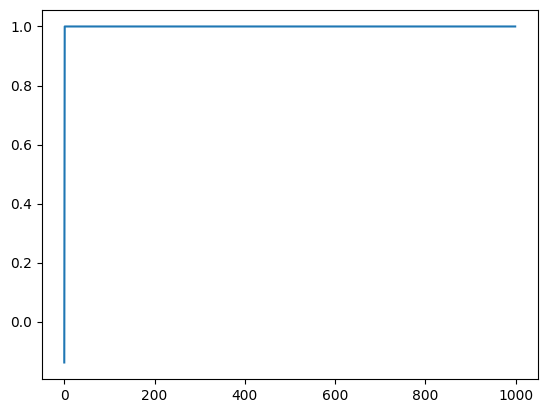

In [216]:
plt.plot(
    np.fromiter(map(lambda model: raw_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(predict_counts_from_model(training_sc.X.toarray(), model)), models), dtype=float)
)
#plt.ylim(0, 1)

/var/folders/qm/v_v5_1r52bx792m7x2mh177c0000gn/T/ipykernel_79719/3876470732.py:20: RuntimeWarning: invalid value encountered in log
  np.log(result.predicted_counts.mean(axis=0) + 1e-3),


(0.0, 1.0)

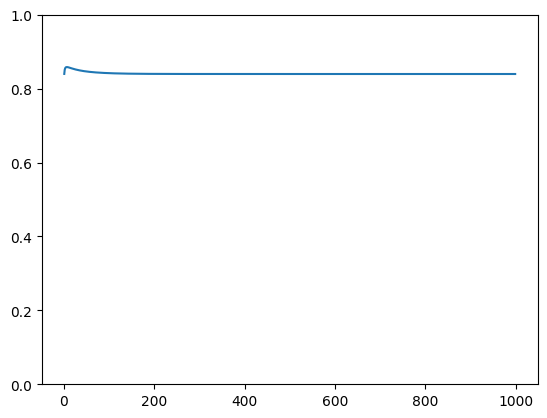

In [212]:
plt.plot(
    np.fromiter(map(lambda model: transform_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(predict_counts_from_model(testing_sp.X, model)), models), dtype=float)
)
plt.ylim(0,1)

In [182]:
list(map(lambda a, b: a + b), itertools.product([1,2],[5,6]))

TypeError: map() must have at least two arguments.

In [ ]:
np.fromiter(map(lambda))

In [178]:
predict_counts_from_model(training_sc.X, models[0])

Result(original_counts=<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7068 stored elements and shape (253, 203)>, predicted_counts=array([[-2.53978962e-02, -1.60853800e-02,  5.00273047e-03, ...,
         7.55549925e-03, -9.43820155e-03,  5.00482667e-03],
       [-9.18665371e-03, -5.81823056e-03,  1.80953383e-03, ...,
         2.73289388e-03, -3.41388470e-03,  1.81029204e-03],
       [-4.37145000e-04, -2.76859287e-04,  8.61062897e-05, ...,
         1.30044185e-04, -1.62448991e-04,  8.61423692e-05],
       ...,
       [-6.03002672e-04, -3.81902778e-04,  1.18775973e-04, ...,
         1.79384394e-04, -2.24083944e-04,  1.18825741e-04],
       [-3.52573482e-04, -2.23297174e-04,  6.94478820e-05, ...,
         1.04885407e-04, -1.31021072e-04,  6.94769814e-05],
       [-1.19088431e-03, -7.54228874e-04,  2.34573492e-04, ...,
         3.54270504e-04, -4.42548707e-04,  2.34671781e-04]]))

In [177]:
models[1](training_sc.X)

array([[ 2.43786325e-04,  1.29108818e-02,  1.25812916e-04, ...,
        -4.86530704e-05,  5.85911036e-05,  4.44088342e-05],
       [ 2.43786325e-04,  1.29108818e-02,  1.25812916e-04, ...,
        -4.86530704e-05,  5.85911036e-05,  4.44088342e-05],
       [ 2.43786325e-04,  1.29108818e-02,  1.25812916e-04, ...,
        -4.86530704e-05,  5.85911036e-05,  4.44088342e-05],
       ...,
       [ 2.43786325e-04,  1.29108818e-02,  1.25812916e-04, ...,
        -4.86530704e-05,  5.85911036e-05,  4.44088342e-05],
       [ 2.43786325e-04,  1.29108818e-02,  1.25812916e-04, ...,
        -4.86530704e-05,  5.85911036e-05,  4.44088342e-05],
       [ 2.43786325e-04,  1.29108818e-02,  1.25812916e-04, ...,
        -4.86530704e-05,  5.85911036e-05,  4.44088342e-05]])

In [167]:
predictions

[array([[ 9.58158655e-02, -1.01283415e-02,  6.18620960e-03, ...,
         -3.94492023e-02,  2.93176732e-02, -5.80441228e-03],
        [ 2.47512490e-02, -3.54915916e-03, -1.52456312e-04, ...,
         -1.09404424e-02,  1.13841932e-02, -2.16291219e-03],
        [ 4.97175758e-02, -5.17496323e-03,  3.36100458e-03, ...,
         -2.04049519e-02,  1.48836844e-02, -2.95457270e-03],
        ...,
        [ 2.53204146e-03, -3.63077361e-04, -1.55962111e-05, ...,
         -1.11920226e-03,  1.16459777e-03, -2.21264929e-04],
        [ 1.05315855e-04,  9.48625704e-05,  2.05709908e-04, ...,
          4.18501794e-05, -4.00805518e-04,  6.90158841e-05],
        [ 3.05101707e-03, -3.97544124e-04,  5.61787258e-05, ...,
         -1.31648077e-03,  1.24008362e-03, -2.38198583e-04]]),
 array([[-0.00045292,  0.01286326,  0.00012508, ...,  0.00021959,
         -0.00016565,  0.00011178],
        [-0.00045292,  0.01286326,  0.00012508, ...,  0.00021959,
         -0.00016565,  0.00011178],
        [-0.00045292,  0.

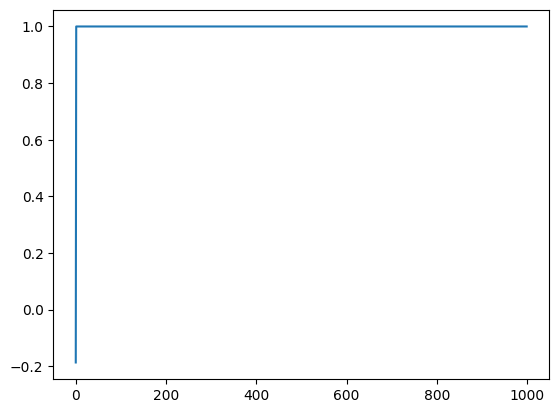

In [163]:
plt.plot(training_error)

In [87]:
class Result(NamedTuple):
    original_counts: np.ndarray
    predicted_counts: np.ndarray

In [86]:
def predict_counts_from_model(
    counts,
    model,
):
    return Result(
        counts,
        model(counts)
    )

In [299]:
raw_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(
    predict_counts_from_model(training_sc.X.toarray(), model)
)

0.9999998398012793

In [300]:
transform_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(
    predict_counts_from_model(training_sc.X.toarray(), model)
)

/var/folders/qm/v_v5_1r52bx792m7x2mh177c0000gn/T/ipykernel_79719/3876470732.py:20: RuntimeWarning: invalid value encountered in log
  np.log(result.predicted_counts.mean(axis=0) + 1e-3),


nan

In [301]:
raw_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(
    predict_counts_from_model(testing_sc.X.toarray(), model)
)

0.996491132969948

In [302]:
transform_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(
    predict_counts_from_model(testing_sc.X.toarray(), model)
)

/var/folders/qm/v_v5_1r52bx792m7x2mh177c0000gn/T/ipykernel_79719/3876470732.py:20: RuntimeWarning: invalid value encountered in log
  np.log(result.predicted_counts.mean(axis=0) + 1e-3),


nan

In [148]:
transform_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))(
    predict_counts_from_model(testing_sp.X, model)
)

0.8395120255696498

In [128]:
predict_counts_from_model(training_sc.X.toarray(), model)

Result(original_counts=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), predicted_counts=array([[ 3.95256917e-03,  6.40316206e-01,  7.90513834e-03, ...,
        -8.94093194e-19,  5.94505425e-19,  3.95256917e-03],
       [ 3.95256917e-03,  6.40316206e-01,  7.90513834e-03, ...,
        -8.94093194e-19,  5.94505425e-19,  3.95256917e-03],
       [ 3.95256917e-03,  6.40316206e-01,  7.90513834e-03, ...,
        -8.94093194e-19,  5.94505425e-19,  3.95256917e-03],
       ...,
       [ 3.95256917e-03,  6.40316206e-01,  7.90513834e-03, ...,
        -8.94093194e-19,  5.94505425e-19,  3.95256917e-03],
       [ 3.95256917e-03,  6.40316206e-01,  7.90513834e-03, ...,
        -8.94093194e-19,  5.94505425e-19,  3.95256917e-03],
       [ 3.95256917e-03,  6.40316206e-01,  7.90513834e-03, ...,
       

In [104]:
spearmanr(
    filter_by_obs(adata_sc, "celltype", "Stem/TA")[:, shared_genes].X.toarray().mean(axis=0),
    model(filter_by_obs(adata_sc, "celltype", "Stem/TA")[:, shared_genes].X.toarray()).mean(axis=0)
)

SignificanceResult(statistic=np.float64(0.9384404886949325), pvalue=np.float64(9.777844718596989e-95))

PearsonRResult(statistic=np.float64(0.5988788327508899), pvalue=np.float64(3.813959848331997e-21))


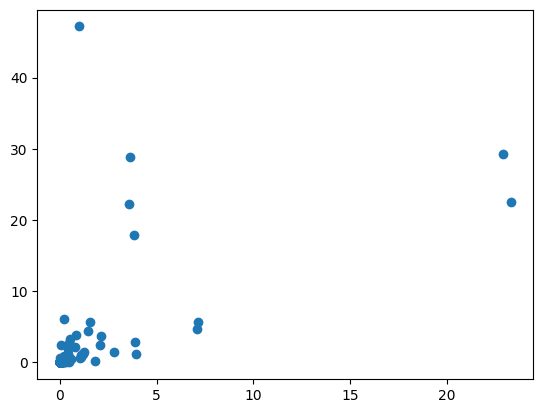

In [121]:
print(pearsonr(
    filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray().mean(axis=0),
    model(filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray()).mean(axis=0)
))
plt.scatter(
    filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray().mean(axis=0),
    model(filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray()).mean(axis=0)
)

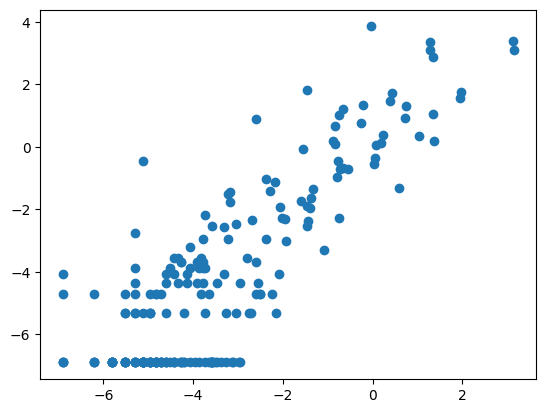

In [115]:
plt.scatter(
    np.log(filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray().mean(axis=0) + 1e-3),
    np.log(model(filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray()).mean(axis=0) + 1e-3)
)

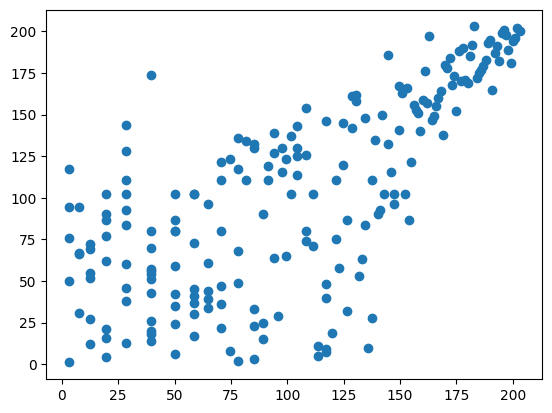

In [118]:
plt.scatter(
    rankdata(filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray().mean(axis=0)),
    rankdata(model(filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray()).mean(axis=0))
)

In [112]:
spearmanr(
    filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray().mean(axis=0),
    model(filter_by_obs(adata_sp, "celltype", "Stem/TA")[:, shared_genes].X.toarray()).mean(axis=0)
)

SignificanceResult(statistic=np.float64(0.7099095527020616), pvalue=np.float64(1.9720946152519506e-32))